In [246]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
# from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator, StatevectorSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes,RZGate, PauliEvolutionGate, HamiltonianGate
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.ticker as ticker
#from qiskit.circuit.library.generalized_gates import RXXGate, RYYGate, RZZGate
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import RGate, ZGate, MCXGate
from qiskit.circuit import Gate
from scipy.linalg import expm
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from qiskit_ibm_runtime import SamplerV2 as Sampler
#from tqdm import tqdm
import time
from qiskit.quantum_info import Operator
from qiskit.providers import JobStatus


In [247]:
from qiskit.quantum_info import Operator, Pauli
from qiskit.quantum_info.operators import SparsePauliOp
from scipy.linalg import expm
from scipy.linalg import svd
from scipy.constants import physical_constants
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

In [248]:
# noiseless implementation
#sampler = StatevectorSampler()
simulator=AerSimulator()

In [249]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####

def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP, cp_sign=1):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)

    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U
    return U_4x4


theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0
N = 2

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
print(mu)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
print (omega, Omega)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

def theta_ij(i, j):
    return np.arccos(0.9) * np.abs(i-j) / (N-1)

def J_ij(i, j, E):
    return  mu/(N) * (1 - np.cos(theta_ij(i, j))) * 1
print(theta_ij(0,1))
print (J_ij(0,1,E))

0.002505
3.705e-05 0.0012525
0.45102681179626236
0.00012524999999999995


In [250]:
### U1 from Eq. C16: single-particle evolution ###
def U1_omega_Omega(qc, t):
    A =  -1 * omega * t 
    B_val =  -1 * Omega * t
    #print (A, B_val)
    qc = QuantumCircuit(2)
    qc.rz(A, 0)      # First qubit: Rz(B)
    qc.rz(B_val, 1)         # Second qubit: Rz(-A)

    return qc.to_gate(label='U1_omega_Omega')



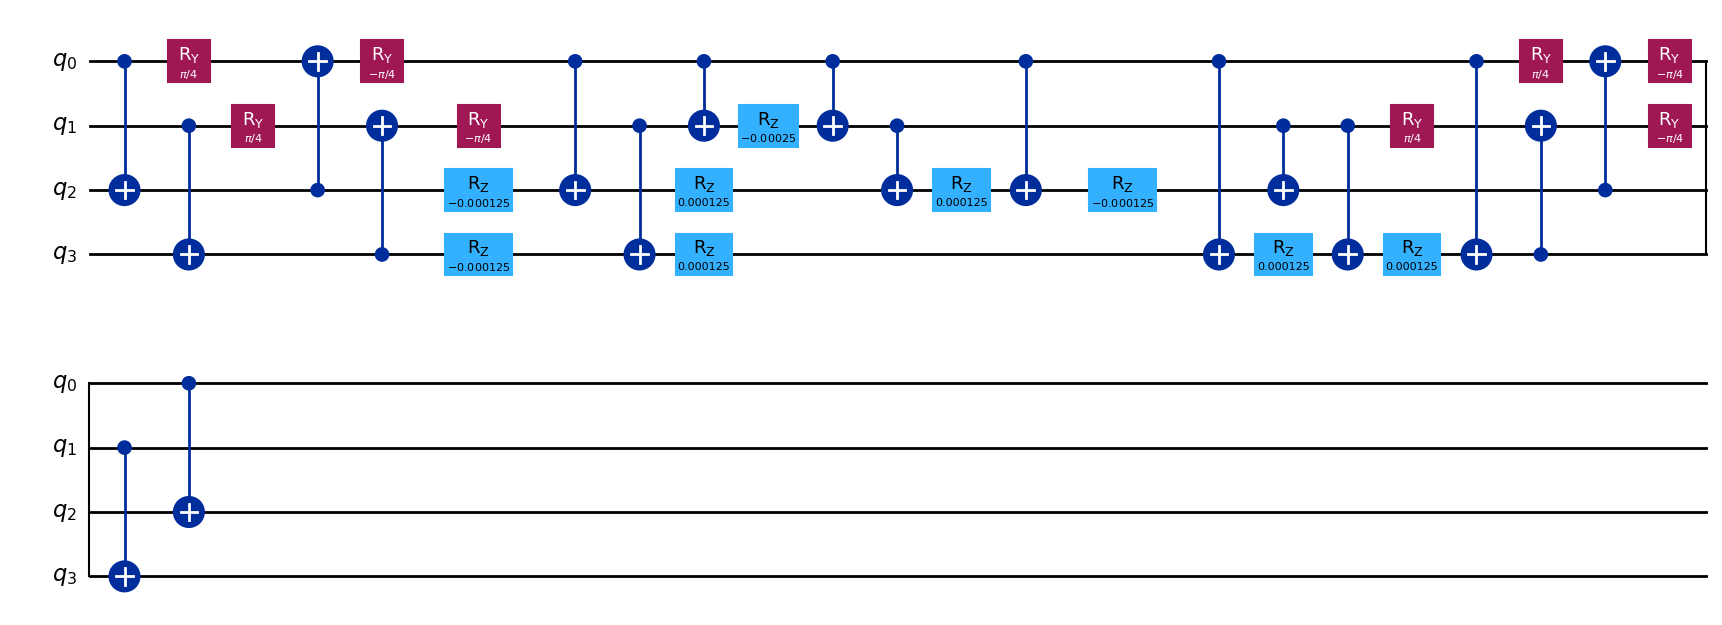

In [251]:
def nunu_interaction(qc, alpha):
    # Apply CNOT gates
    qc.cx(0, 2)
    qc.cx(1, 3)
    # Apply Ry(pi/4) to q0 and q1
    qc.ry(1 * np.pi/4, 0)
    qc.ry(1 * np.pi/4, 1)

    # CNOTs to q2 and q3
    qc.cx(2, 0)
    qc.cx(3, 1)

    # Apply Ry(-pi/4) to q0 and q1
    qc.ry(-1 * np.pi/4, 0)
    qc.ry(-1 * np.pi/4, 1)
    # Apply Rz(-alpha) to q2 and q3
    qc.rz(-1 * alpha, 2)
    qc.rz(-1 * alpha, 3)    
    # CNOT gates 
    qc.cx(0, 2)
    qc.cx(1, 3)
    qc.cx(0, 1)
    # Rz(-2α) on q1
    qc.rz(-1 * 2 * alpha, 1)
    # Rz(α) on q2 and q3
    qc.rz(1 * alpha, 2)
    qc.rz(1 * alpha, 3)
    #CNOT gates
    qc.cx(0, 1)
    qc.cx(1, 2)
    
    # Rz(α) on q2
    qc.rz(1 * alpha, 2)
    # CNOT gates
    qc.cx(0, 2)
    # Rz(-α) on q2
    qc.rz(-1 * alpha, 2)
    # CNOT gates
    qc.cx(0, 3)
    qc.cx(1, 2)
    # Rz(α) on q3
    qc.rz(1 * alpha, 3)
    # CNOT
    qc.cx(1, 3)
    # Rz(-α) on q3
    qc.rz(1 * alpha, 3)
    #CNOT
    qc.cx(0, 3)
    
    # Closing gates: Ry(pi/4), CNOTs, Ry(-pi/4), CNOT
    qc.ry(1 * np.pi/4, 0)
    qc.ry(1 * np.pi/4, 1)
    qc.cx(3, 1)
    qc.cx(2, 0)
    qc.ry(-1 * np.pi/4, 0)
    qc.ry(-1 * np.pi/4, 1)
    qc.cx(1, 3)
    qc.cx(0, 2)
    

# Build and apply the gates
J = J_ij(0, 1, E)
t = 1.0
alpha=J * t
qc = QuantumCircuit(4)
nunu_interaction(qc, alpha=alpha)
qc.draw('mpl')
    

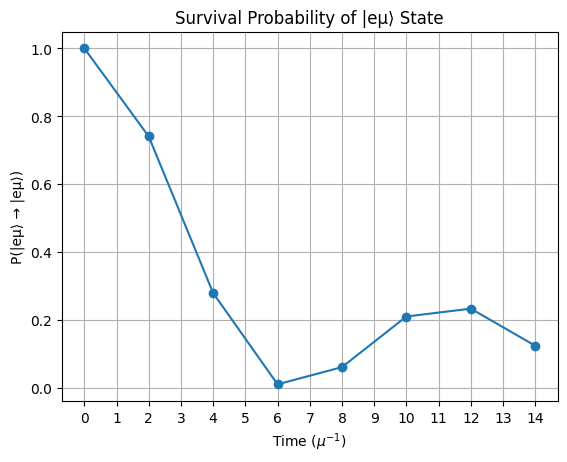

In [252]:
# Time loop setup
dt = 2 / mu  # dt = 0.5 mu^-1
T_max = 14 / mu  # simulate from t=0 to t=5 mu^-1
steps = int(T_max / dt) + 1
times = np.linspace(0, T_max, steps)

probabilities = []
shots=8192
for t in times:
    # Step 1: Initial statevector

    # Prepare |emu⟩ = |0001⟩
    qc = QuantumCircuit(4, 4)
      
    qc.x(3)
    
    
    #sv = Statevector.from_instruction(qc)
    #print("Initial state:", sv)
    # Step 2: Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    qc.unitary(Udag, [0, 1], label="U†_PMNS")
    qc.unitary(Udag, [2, 3], label="U†_PMNS")
    #sv = sv.evolve(qc)
    #print("After U†_PMNS:", sv)
    Trotter = int(t/dt)
    for trotter in range(Trotter):     ##Trotterization
        alpha=1 * J * dt
    # Step 3: Apply individual evolution
        if dt>0:
            qc.append(U1_omega_Omega(qc, dt), [0, 1])
            qc.append(U1_omega_Omega(qc, dt), [2, 3])
    # Step 4: Apply interaction
        if dt>0:
            nunu_interaction(qc, alpha=alpha)
    #sv = sv.evolve(qc)
    #print("After nunu interaction:", sv)
    # Step 4: Apply U_PMNS
    U = Operator(U_PMNS_4x4)
    qc.unitary(U, [0, 1], label="U_PMNS")
    qc.unitary(U, [2, 3], label="U_PMNS")
    #sv = sv.evolve(qc)
    #print("After U_PMNS:", sv)
     # Step 5: Measurement
    qc.measure(range(4), reversed(range(4)))
    initial_layout = [0, 1]
    pqc = transpile(qc, simulator)
    #job = sampler.run([pqc], shots=shots)
    job = simulator.run([pqc], shots=shots)
    job_result = job.result()
    #counts = job_result[0].data.c.get_counts()
    counts = job_result.get_counts()
    prob = counts.get('0001', 0) / shots
    #amplitude = sv.data[8]
    #index = 1  # for |0001⟩ in big-endian
    ##prob = np.abs(amplitude)**2
    #print(prob)
    probabilities.append(prob)

# Plot
plt.plot(times*mu , probabilities, marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.xticks(ticks=[i for i in range(15)], labels=[str(i) for i in range(15)])
plt.ylabel("P(|eμ⟩ → |eμ⟩)")
plt.title("Survival Probability of |eμ⟩ State")
plt.grid(True)
plt.show()
